In [5]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler

In [8]:
# [1] 데이터셋 구성 - TESS + RAVDESS + 감정 필터링

import os
import librosa
import numpy as np

# 경로 설정
TESS_path = r'C:\Users\a\kimleepark\TESS Toronto emotional speech set data'
RAVDESS_path = r'C:\Users\a\kimleepark\Ravdess_by_emotion'

# 사용할 감정
selected_emotions = ['angry', 'happy', 'neutral', 'sad']
emotion_map = {emotion: idx for idx, emotion in enumerate(selected_emotions)}

# 데이터 저장 리스트
speech_data = []
speech_labels = []

# 데이터 로딩
for base_path in [TESS_path, RAVDESS_path]:
    for folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder)

        # 감정이 폴더 이름에 포함되어 있는지 확인
        for emotion in selected_emotions:
            if emotion in folder.lower():
                for file in os.listdir(folder_path):
                    if file.endswith('.wav'):
                        # 오디오 로딩
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        # MFCC 100차원 추출
                        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=100)
                        mfcc_scaled = np.mean(mfcc.T, axis=0)
                        speech_data.append(mfcc_scaled)
                        speech_labels.append(emotion_map[emotion])
                break  # 중복 방지


In [9]:
from collections import Counter

# 숫자 인덱스를 감정 이름으로 다시 매핑
label_names = {v: k for k, v in emotion_map.items()}

# 각 감정별 샘플 수 계산
label_counts = Counter(speech_labels)

# 결과 출력
for label_idx in sorted(label_counts):
    emotion = label_names[label_idx]
    count = label_counts[label_idx]
    print(f"{emotion:>7} : {count}개")


  angry : 592개
  happy : 592개
neutral : 496개
    sad : 592개


In [11]:
# [3] 데이터 정규화 및 차원 변환

from sklearn.preprocessing import StandardScaler
import numpy as np

# 스케일러 정의 및 학습
scaler = StandardScaler()
speech_data_scaled = scaler.fit_transform(speech_data)

# Conv1D 입력 형식에 맞게 마지막 축 추가 → (샘플 수, 100, 1)
X = np.expand_dims(speech_data_scaled, axis=-1)

# 라벨을 넘파이 배열로 변환
y = np.array(speech_labels)

In [12]:
#  [4] Conv1D 기반 CNN 모델 구성 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 모델 구성
model = Sequential()
model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(100, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(selected_emotions), activation='softmax'))  # 클래스 수만큼 출력

# 모델 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()  # 모델 구조 확인


C:\Users\a\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 96, 64)              │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         196,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 197,316 (770.77 KB)

 Trainable params: 197,316 (770.77 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# [5] 학습/검증 데이터 분리 + 모델 학습

# 라이브러리
from sklearn.model_selection import train_test_split

# 학습용/검증용 데이터 분리
# 1차: 학습 vs 나머지 (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2차: 검증 vs 테스트 (15%씩)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0354 - val_accuracy: 0.9384 - val_loss: 0.1991
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0238 - val_accuracy: 0.9384 - val_loss: 0.2263
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9947 - loss: 0.0244 - val_accuracy: 0.9296 - val_loss: 0.2266
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9963 - loss: 0.0234 - val_accuracy: 0.9326 - val_loss: 0.2158
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0227 - val_accuracy: 0.9326 - val_loss: 0.2524
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9965 - loss: 0.0193 - val_accuracy: 0.9472 - val_loss: 0.2346
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9985 - loss: 0.0165 - val_accuracy: 0.9326 - val_loss: 0.2617
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9961 - loss: 0.0159 - val_accuracy: 0.9326 - val_loss:

In [16]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ 최종 테스트 정확도: {accuracy*100:.2f}%")


✅ 최종 테스트 정확도: 93.26%


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


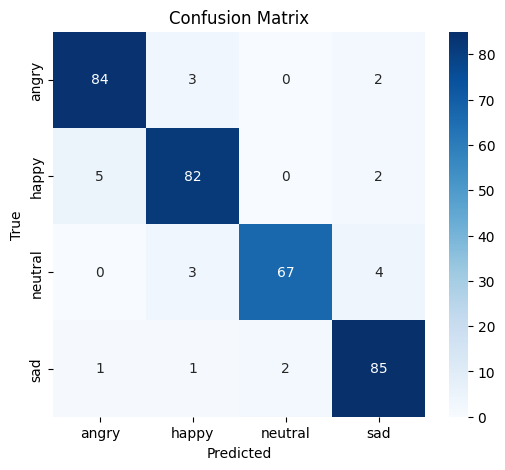


 Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.94      0.94        89
       happy       0.92      0.92      0.92        89
     neutral       0.97      0.91      0.94        74
         sad       0.91      0.96      0.93        89

    accuracy                           0.93       341
   macro avg       0.93      0.93      0.93       341
weighted avg       0.93      0.93      0.93       341



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 테스트셋 예측
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# 2. Confusion Matrix 계산
cm = confusion_matrix(y_true, y_pred)

# 3. 클래스 라벨 정의 
emotion_labels = ['angry', 'happy', 'neutral', 'sad']

# 4. Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5. Classification Report 출력
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))



In [19]:
import joblib

scaler = StandardScaler()
speech_data_scaled = scaler.fit_transform(speech_data)

joblib.dump(scaler, 'scaler.save')  # 현재 작업 디렉토리에 저장됨


['scaler.save']

In [20]:
# 모델 저장
model.save("audio_emotion_model.keras")
